# Chain Summary Bars

Bar-style chain comparison plots, following the region-split notebook style but using reusable helpers from `plotting_tools.py`.


In [66]:
import os
import sys
import itertools
from pathlib import Path

# This notebook only loads/plots saved results; keep JAX from probing or reserving GPU memory.
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
os.environ['CUDA_VISIBLE_DEVICES'] = ''
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['MPICH_GPU_SUPPORT_ENABLED'] = '0'

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from desilike.samples import Chain

main_dir = Path('/global/homes/s/shengyu/Y3/desi_y3_redshift_errors/main')
if str(main_dir) not in sys.path:
    sys.path.insert(0, str(main_dir))

from helper import REDSHIFT_BIN_TRACER
from cat_tools import parse_zerr_name
from fit_tools import LikelihoodBuilder, get_fits_fn
from plotting_tools import PLANCK_COSMOLOGY, make_key, chain_fit_results, PARAM_LABELS
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",   # Computer Modern-like math
    "font.family": "serif",
})

OVERLEAF_DIR = '/global/homes/s/shengyu/Y3/desi_y3_redshift_errors/overleaf/figures'
FITS_DIR = Path('/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits')

%load_ext autoreload
%autoreload 2

save_fig = True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
## Fiducial settings
version= 'AbacusHF-v2'
mockids = range(25)
cov_version = 'holi-v3'

cosmo_params = 'base'
theory_model = 'folpsD'
prior_basis = 'physical_aap'

KRANGES = {
    'mesh2': [
        {'ells': 0, 'k': [0.02, 0.35, 0.01]},
        {'ells': 2, 'k': [0.02, 0.25, 0.01]},
        # {'ells': 4, 'k': [0.02, 0.300, 0.01]},
    ],
    'mesh3': [
        {'ells': (0, 0, 0), 'k': [0.02, 0.20, 0.01]},
        {'ells': (2, 0, 2), 'k': [0.02, 0.08, 0.01]},
    ],
}

# KRANGES = {
#     'mesh2': [
#         {'ells': 0, 'k': [0.02, 0.30, 0.01]},
#         {'ells': 2, 'k': [0.02, 0.30, 0.01]},
#         # {'ells': 4, 'k': [0.02, 0.300, 0.01]},
#     ],
#     'mesh3': [
#         {'ells': (0, 0, 0), 'k': [0.02, 0.20, 0.01]},
#         {'ells': (2, 0, 2), 'k': [0.02, 0.08, 0.01]},
#     ],
# }

step = 2
analysis_settings = {
    'smooth_scale_1D': 0.6,
    'smooth_scale_2D': 0.6,
    'fine_bins': 1024,
    'fine_bins_2D': 512,
}

In [68]:
TRACERS = ['LRG1', 'LRG2', 'LRG3', 'QSO1'][3:]
ZERRS = [False, 'verr_nonparam'][:]
STATS = [['mesh2'], ['mesh2', 'mesh3']][1:]

params = ['H0', 'Omega_m', 'sigma8_m']
# params = ['h', 'omega_cdm', 'logA']

In [69]:
chains_by_key = {}

for tracer, zerr, stats in itertools.product(TRACERS, ZERRS, STATS):
    zrange = REDSHIFT_BIN_TRACER[tracer]
    if 'LRG' in tracer:
        domain = 'altmtl'
        hod = 'base'
    elif 'QSO' in tracer:       
        domain = 'cutsky'
        hod = 'base_dv' 

    use_dv, z_evol = parse_zerr_name(zerr)
    observables = [{'stat': {'kind': stat, 'select': KRANGES[f"{stat}"]},
                'theory': {'model': 'folpsD', 'prior_basis': "physical_aap"},
                } for stat in stats]
    data_args = {'version': version, 'domain':domain, 'tracer':tracer, 'zrange': zrange, 'hod': hod,
                 'mock_ids': mockids, 'region': 'ALL', "use_dv": use_dv, "z_evol": z_evol}
    covariance_args = {'source': 'mock', 'version': cov_version, 'mock_ids': range(1000),
                        'corrections': ['hartlap', 'percival'], 'rescale': False, 'domain': 'altmtl'}
    cosmology_args = {'model': cosmo_params, 'template': 'direct'}
    fit_args = dict(observables=observables, catalog=data_args, covariance=covariance_args,
                    cosmology=cosmology_args, cache_dir=FITS_DIR / '_cache')
    builder = LikelihoodBuilder(**fit_args)

    stat_label = '+'.join(stats)
    chain_key = f"{tracer}_{stat_label}_{use_dv}"
    chain_fn = builder.get_fits_fn(fits_dir=FITS_DIR, kind='chain', ichain=0)
    if not chain_fn.is_file():
        print(f"Chain file not found: {chain_fn}")
        continue
    chain = Chain.load(chain_fn).remove_burnin(0.5)[::step]


    fit_results = chain_fit_results(chain, params=params)
    for param in fit_results:
        try:
            fit_results[param]['std'] = float(chain.std(params=param))
        except AttributeError:
            pass


    chain = chain.to_getdist(params=params+['n_s', f'{tracer}.b1p', f'{tracer}.b2p', f'{tracer}.bsp', f'{tracer}.X_FoG_pp',
                                            f'{tracer}.alpha0p', f'{tracer}.alpha2p', f'{tracer}.sn0p', f'{tracer}.sn2p'], 
                                            settings=analysis_settings)
    param_names = chain.getParamNames()
    for param in param_names.names:
        label = PARAM_LABELS.get(param.name, param.name)
        if label.startswith('$') and label.endswith('$'):
            label = label[1:-1]
        if param.name.endswith('.b1p'):
            label = r'b_1'
        elif param.name.endswith('.b2p'):
            label = r'b_2'
        elif param.name.endswith('.bsp'):
            label = r'b_s'
        elif param.name.endswith('.X_FoG_pp'):
            label = r'X_{FoG}'
        elif param.name.endswith('.alpha0p'):
            label = r'\alpha_0'
        elif param.name.endswith('.alpha2p'):
            label = r'\alpha_2'
        elif param.name.endswith('.sn0p'):
            label = r's_{n,0}'
        elif param.name.endswith('.sn2p'):
            label = r's_{n,2}'
        param.label = label
    chain.setParamNames(param_names)

    chains_by_key[chain_key] = {
        'chain': chain,
        'args': [data_args, covariance_args, cosmology_args],
        'fit_results': fit_results,
        'stats': list(stats),
        'stat_label': stat_label,
    }

[000555.92]  07-08 03:32  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-879d6599/chain_0.npy.
Removed no burn in
[000556.01]  07-08 03:32  Chain                        INFO     Loading /global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-e13ffaa9/chain_0.npy.


Removed no burn in


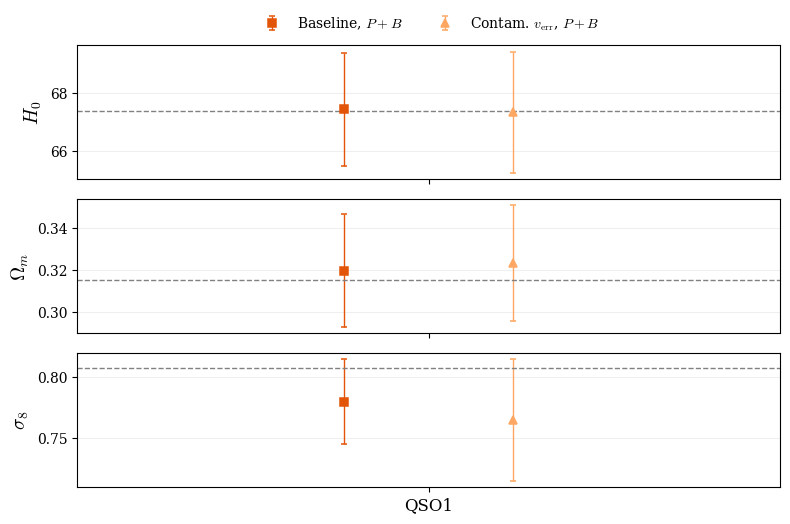

In [20]:
from plotting_tools import plot_chain_comparison

fig = plot_chain_comparison(
    chains_by_key,
    params=params,
    tracers=TRACERS,
    fit_labels=['standard', 'verr_nonparam'],
    stat_labels=['mesh2', 'mesh2+mesh3'],
    fit_label_display={
        'standard': 'Baseline',
        'verr_nonparam': r'Contam. $v_{\rm{err}}$',
    },
    stat_label_display={
        'mesh2': f'$P$',
        'mesh2+mesh3': r'$P+B$',
    },
    stat_cmaps={
        'mesh2': 'Blues',
        'mesh2+mesh3': 'Oranges',
    },
    markers=('s', '^'),
)

if save_fig == True:
    fig.savefig(OVERLEAF_DIR+f'/plot_fits_comparison.pdf', bbox_inches='tight')

In [70]:
def _getdist_weighted_mean_cov(chain, params):
    names = [name.name for name in chain.getParamNames().names]
    indices = [names.index(param) for param in params]
    samples = np.asarray(chain.samples)[:, indices]
    weights = np.asarray(chain.weights, dtype=float)
    weights = weights / weights.sum()
    mean = np.average(samples, axis=0, weights=weights)
    centered = samples - mean
    cov = (centered * weights[:, None]).T @ centered
    cov *= 1.0 / (1.0 - np.sum(weights**2))
    return mean, cov

def chain_tensions(chain_clean, chain_verr, params):
    mean_clean, cov_clean = _getdist_weighted_mean_cov(chain_clean, params)
    mean_verr, cov_verr = _getdist_weighted_mean_cov(chain_verr, params)
    delta = mean_verr - mean_clean
    cov_delta = cov_clean
    # param_tensions = np.abs(delta) / np.sqrt(np.diag(cov_delta))
    param_tensions = delta / np.sqrt(np.diag(cov_clean))
    # FoB relative to the baseline fit uses only the baseline covariance.
    fob = np.sqrt(delta @ np.linalg.pinv(cov_delta) @ delta)
    return dict(zip(params, param_tensions)) | {'FoB': float(fob)}

tension_rows = []
stat_cases = {
    'Pk': 'mesh2',
    'Pk+Bk': 'mesh2+mesh3',
}

for tracer in TRACERS:
    for case_label, stat_label in stat_cases.items():
        row = {'tracer': tracer, 'case': case_label}
        clean_key = f'{tracer}_{stat_label}_None'
        verr_key = f'{tracer}_{stat_label}_verr_nonparam'
        if clean_key not in chains_by_key or verr_key not in chains_by_key:
            row.update({param: np.nan for param in params})
            row['FoB'] = np.nan
            tension_rows.append(row)
            continue
        row.update(chain_tensions(
            chains_by_key[clean_key]['chain'],
            chains_by_key[verr_key]['chain'],
            params,
        ))
        tension_rows.append(row)

tension_table = pd.DataFrame(tension_rows)
tension_table = tension_table.set_index(['tracer', 'case'])
tension_table.style.format({col: "{:.2f}" for col in params + ['FoB']})

# if save_fig == True:
    # fig.savefig(OVERLEAF_DIR + '/clean_verr_sigma_tension_table.pdf', bbox_inches='tight')

In [71]:
print(chains_by_key['QSO1_mesh2+mesh3_None']['fit_results']['sigma8_m'])
print(chains_by_key['QSO1_mesh2+mesh3_verr_nonparam']['fit_results']['sigma8_m'])

print(chains_by_key['QSO1_mesh2+mesh3_verr_nonparam']['fit_results']['sigma8_m']['std']/chains_by_key['QSO1_mesh2+mesh3_None']['fit_results']['sigma8_m']['std'])

{'mean': 0.7669252344995539, 'median': 0.7668320628820554, 'q16': 0.7366957727496735, 'q84': 0.7972275351220189, 'std': 0.030336761787899822}
{'mean': 0.7188678771649808, 'median': 0.7183726722492166, 'q16': 0.6894975514551264, 'q84': 0.7483280624085789, 'std': 0.02943900473322461}
0.9704069583645116


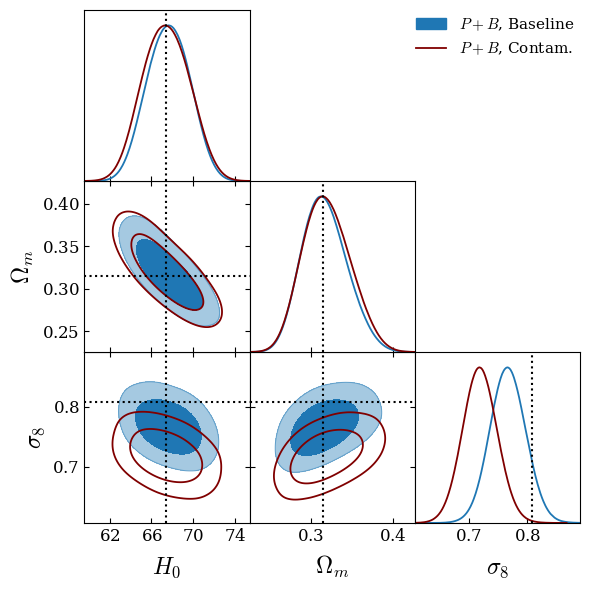

In [ ]:
from getdist import MCSamples, plots
# fn = '/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-b0b2129b/chain_0.npy'
# chain = Chain.load(fn).remove_burnin(0.5)[::step].to_getdist(params=params, settings=analysis_settings)

chain1 = chains_by_key['QSO1_mesh2+mesh3_None']['chain']
chain2 = chains_by_key['QSO1_mesh2+mesh3_verr_nonparam']['chain']
chains = [chain1, chain2]

# plot_params = params+['QSO1.b1p', 'QSO1.b2p', 'QSO1.bsp', 'QSO1.X_FoG_pp', 'QSO1.alpha0p', 'QSO1.alpha2p', 'QSO1.sn0p', 'QSO1.sn2p'][:3]
plot_params = params

g = plots.get_subplot_plotter()
g.settings.fig_width_inch = len(plot_params) * 2
g.settings.legend_fontsize = 14
g.settings.axes_labelsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.settings.num_plot_contours = 2

g.triangle_plot(
    chains,
    plot_params,
    legend_loc='upper right',
    legend_labels=[r'$P+B$, Baseline', r'$P+B$, Contam.', r'$P+B$, contam.+Corr'],
    contour_lws=1.3,
    contour_colors=['C0', 'maroon', 'darkgreen'],
    contour_ls = ['-', '-', '--'],
    filled = [True, False, False]
)

# from plotting_tools import PLANCK_COSMOLOGY
true_values = PLANCK_COSMOLOGY
for i, pi in enumerate(plot_params[:3]):
    for j, pj in enumerate(plot_params[:i+1]):
        ax = g.subplots[i, j]
        ax.axvline(true_values[pj], c='k', ls=':', lw=1.5)
        if i != j:
            ax.axhline(true_values[pi], c='k', ls=':', lw=1.5)

# if save_fig == True:
#     g.export(OVERLEAF_DIR+'/corner_QSO_PB.pdf')

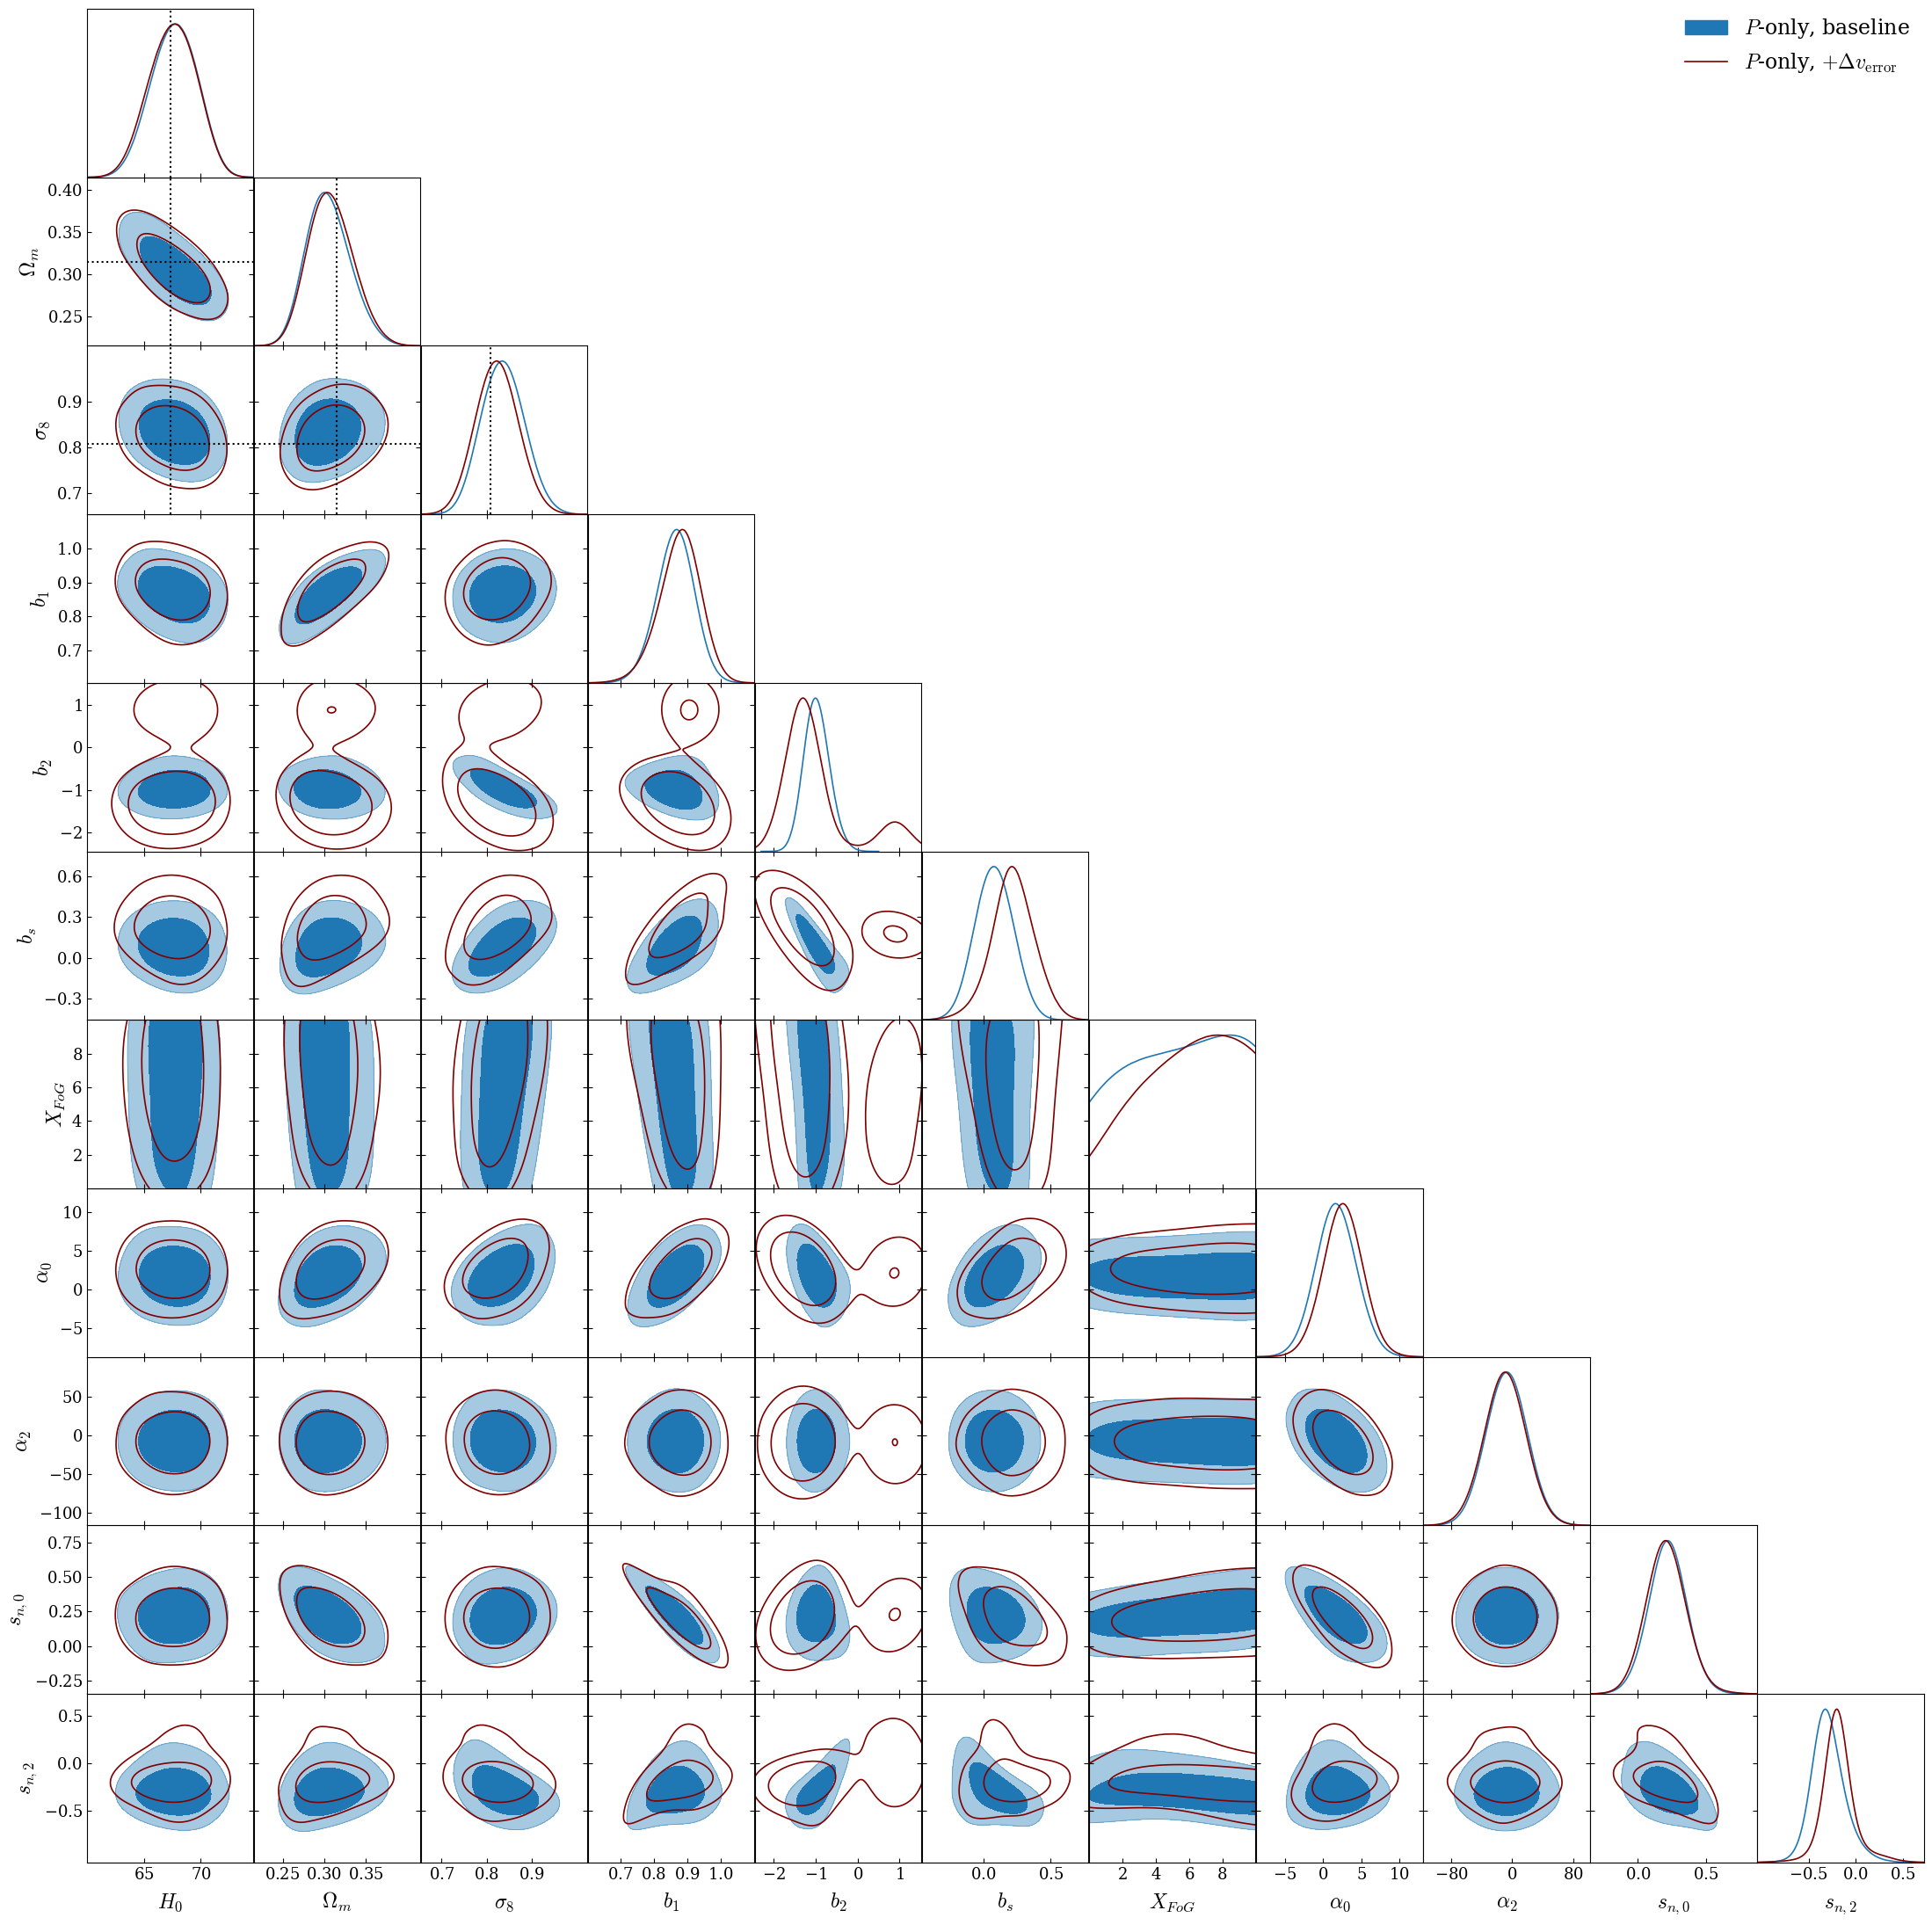

In [7]:
from getdist import MCSamples, plots
# fn = '/global/cfs/cdirs/desi/users/shengyu/Y3/full-shape/redshift_errors/fits/cosmo-base_QSO1-z0.8-2.1-mean25-S2+QSO1-z0.8-2.1-mean25-S3-b0b2129b/chain_0.npy'
# chain = Chain.load(fn).remove_burnin(0.5)[::step].to_getdist(params=params, settings=analysis_settings)

chain1 = chains_by_key['QSO1_mesh2_None']['chain']
chain2 = chains_by_key['QSO1_mesh2_verr_nonparam']['chain']
chains = [chain1, chain2]

plot_params = params
plot_params += ['QSO1.b1p', 'QSO1.b2p', 'QSO1.bsp', 'QSO1.X_FoG_pp', 'QSO1.alpha0p', 'QSO1.alpha2p', 'QSO1.sn0p', 'QSO1.sn2p'][:]
# plot_params = params

g = plots.get_subplot_plotter()
g.settings.fig_width_inch = len(plot_params) * 2
g.settings.legend_fontsize = 20
g.settings.axes_labelsize = 20
g.settings.axes_fontsize = 16
g.settings.figure_legend_frame = False
g.settings.num_plot_contours = 2

g.triangle_plot(
    chains,
    plot_params,
    legend_loc='upper right',
    legend_labels=[r'$P$-only, baseline', r'$P$-only, $+\Delta v_{\rm{error}}$'],
    contour_lws=1.2,
    contour_colors=['C0', 'maroon'],
    contour_ls = ['-', '-'],
    filled = [True, False]
)

# from plotting_tools import PLANCK_COSMOLOGY
true_values = PLANCK_COSMOLOGY
for i, pi in enumerate(plot_params[:3]):
    for j, pj in enumerate(plot_params[:i+1]):
        ax = g.subplots[i, j]
        ax.axvline(true_values[pj], c='k', ls=':', lw=1.5)
        if i != j:
            ax.axhline(true_values[pi], c='k', ls=':', lw=1.5)